In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
# 1. Load dữ liệu
df = pd.read_csv("training_data_final.csv", parse_dates=["Datetime"], index_col="Datetime")

# Chọn cột GOLD để dự đoán
data = df[["Gold"]]

In [7]:
# 2. Tiền xử lí dữ liệu
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [8]:
# 3. Tạo tập dữ liệu huấn luyện và kiểm tra
X, y = [], []
window = 60  # 60 phút trước

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])  
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [9]:
# 4.Reshape dữ liệu cho LSTM (3D)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
# Chia train/test theo thời gian
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [10]:
# 5.Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


c:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# 6. Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0292 - val_loss: 5.5255e-04
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.2237e-04 - val_loss: 3.0114e-05
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.5239e-04 - val_loss: 1.9491e-05
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.0372e-04 - val_loss: 3.4659e-07
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 7.5944e-04 - val_loss: 4.6861e-06
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 7.2956e-04 - val_loss: 1.0336e-04
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 6.8044e-04 - val_loss: 1.0747e-13
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 6.6332e-04 - val_loss: 2.5362e-05
Epoch 9/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 6.0442e-04 - val_loss: 5.3456e-05
Epoch 10/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 5.7801e-04 - val_loss: 4.6712e-06
Epoch 11/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step

In [12]:
# 7. Dự đoán
y_pred_scaled = model.predict(X_test)

# Chuyển từ [0,1] về giá thật
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [13]:
# 8. Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 0.015903968059518023
R² score: 0.9894014794555853


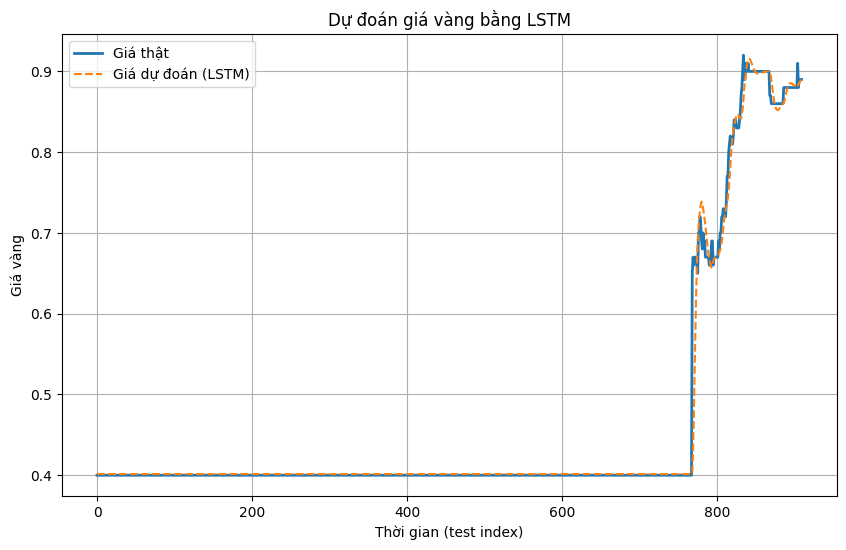

In [15]:
# 9. Vẽ biểu đồ dự đoán
plt.figure(figsize=(10,6))
plt.plot(y_test_real, label="Giá thật", linewidth=2)
plt.plot(y_pred, label="Giá dự đoán (LSTM)", linestyle='--')
plt.title("Dự đoán giá vàng bằng LSTM")
plt.xlabel("Thời gian (test index)")
plt.ylabel("Giá vàng")
plt.legend()
plt.grid(True)
plt.show()
